# **Programación Evolutiva y Problemas Multiobjetivo**
## NSGA-II: Frente de Pareto — Original vs. Modificado

**Autor:** Kamila  
**Curso:** Computación Bioinspirada / Evolutiva — EIG Business School  
**Referencia:** Guato, M. (2026). *Programación evolutiva y problemas multiobjetivo*. EIG Business School.

---

### Objetivo del notebook

Este notebook implementa, ejecuta y compara **dos versiones del mismo problema de optimización multiobjetivo** usando el algoritmo NSGA-II con la librería `pymoo`:

| Versión | Descripción |
|---------|-------------|
| **Original** | Sin restricciones, RF con crecimiento cuadrático en x1 |
| **Modificada** | Con restricción presupuestaria `1·x1 + 0.8·x2 ≤ 12` y RF con rendimientos decrecientes en x1 |

Cada sección ejecuta ambas versiones y visualiza los resultados lado a lado para facilitar la comparación.

### Contexto del problema

Somos directivos de una empresa y queremos simultáneamente:
- **Maximizar** el Rendimiento Financiero (**RF**)
- **Minimizar** los Gastos Administrativos (**GA**)

Las variables de decisión son:
- **x1 = NIT**: Nivel de Inversión en Nuevas Tecnologías (rango [0, 10])
- **x2 = GES**: Grado de Externalización de Servicios (rango [0, 10])

---
## Sección 1 — Instalación y carga de librerías

**Qué:** Instalamos `pymoo` e importamos todas las dependencias necesarias.  
**Por qué:** `pymoo` es el framework estándar en Python para optimización multiobjetivo con algoritmos evolutivos; provee implementaciones eficientes de NSGA-II, operadores genéticos y utilidades de visualización.  
**Para qué:** Tener un entorno reproducible con todas las herramientas antes de definir ningún problema.

In [1]:
# ── Instalación (ejecutar solo una vez; comentar en ejecuciones posteriores) ──
# !pip install -U pymoo

# ── Importaciones estándar ────────────────────────────────────────────────────
import os                                   # Manejo de directorios
import numpy as np                          # Operaciones numéricas
import matplotlib.pyplot as plt             # Visualización
import matplotlib.gridspec as gridspec      # Control fino de layouts de figuras

# ── Importaciones de pymoo ────────────────────────────────────────────────────
from pymoo.core.problem import ElementwiseProblem   # Clase base para definir problemas
from pymoo.algorithms.moo.nsga2 import NSGA2        # Algoritmo NSGA-II
from pymoo.optimize import minimize                  # Función principal de optimización

# ── Semilla global para reproducibilidad ─────────────────────────────────────
SEED = 1

# ── Directorio de salida para figuras ────────────────────
os.makedirs('outputs', exist_ok=True)

print("✅ Librerías cargadas correctamente.")
import pymoo; print(f"   pymoo versión: {pymoo.__version__}")

✅ Librerías cargadas correctamente.
   pymoo versión: 0.6.1.6


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# PROBLEMA ORIGINAL
# ══════════════════════════════════════════════════════════════════════════════
class ProblemaFinancieroOriginal(ElementwiseProblem):
    """
    Problema original sin restricciones adicionales.
    RF(x1,x2) = (x1+1)^2 + 0.5*x2 - 0.1*x2^2   → maximizar
    GA(x1,x2) = 50/(x2+1) + 0.2*(x1-5)^2 + 5    → minimizar
    """
    def __init__(self):
        super().__init__(
            n_var=2,                        # Dos variables de decisión: x1 (NIT), x2 (GES)
            n_obj=2,                        # Dos objetivos: RF (negado), GA
            n_constr=0,                     # Sin restricciones
            xl=np.array([0.0, 0.0]),        # Límite inferior: ambas variables >= 0
            xu=np.array([10.0, 10.0])       # Límite superior: ambas variables <= 10
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2 = x[0], x[1]

        # ── Objetivo 1: Rendimiento Financiero (RF) ───────────────────────────
        # El RF crece cuadráticamente con x1 (NIT).
        # x2 tiene impacto positivo inicial pero decreciente por el término -0.1*x2^2.
        # Pasamos -RF porque pymoo minimiza y nosotros queremos maximizar.
        rf  = (x1 + 1)**2 + 0.5 * x2 - 0.1 * x2**2
        obj1 = -rf

        # ── Objetivo 2: Gastos Administrativos (GA) ───────────────────────────
        # GA disminuye con x2 (más externalización → menos gastos directos).
        # Existe un coste óptimo de NIT alrededor de x1=5; alejarse de ese punto
        # incrementa los gastos (costes de integración u oportunidad).
        ga   = 50 / (x2 + 1) + 0.2 * (x1 - 5)**2 + 5
        obj2 = ga

        out["F"] = [obj1, obj2]


# ══════════════════════════════════════════════════════════════════════════════
# PROBLEMA MODIFICADO
# ══════════════════════════════════════════════════════════════════════════════
class ProblemaFinancieroModificado(ElementwiseProblem):
    """
    Problema modificado con:
      1. Restricción presupuestaria: 1*x1 + 0.8*x2 <= 12
         → formulada para pymoo como: g(x) = 1*x1 + 0.8*x2 - 12 <= 0
      2. Nueva función RF con rendimientos decrecientes para NIT:
         RF_nuevo(x1,x2) = 10*sqrt(x1+1) + 0.5*x2 - 0.1*x2^2
         El cambio de (x1+1)^2 → 10*sqrt(x1+1) modela que las primeras
         unidades de NIT son muy rentables, pero el beneficio marginal
         se reduce a medida que x1 crece.
    """
    def __init__(self):
        super().__init__(
            n_var=2,
            n_obj=2,
            n_constr=1,                     # UNA restricción de desigualdad
            xl=np.array([0.0, 0.0]),
            xu=np.array([10.0, 10.0])
        )

    def _evaluate(self, x, out, *args, **kwargs):
        x1, x2 = x[0], x[1]

        # ── Objetivo 1: RF con rendimientos decrecientes (nueva fórmula) ──────
        # sqrt(x1+1) crece rápido al principio (x1 cercano a 0) pero se aplana
        # para valores altos de x1, modelando saturación tecnológica.
        rf  = 10 * np.sqrt(x1 + 1) + 0.5 * x2 - 0.1 * x2**2
        obj1 = -rf   # negamos para maximizar

        # ── Objetivo 2: GA idéntico al original ───────────────────────────────
        ga   = 50 / (x2 + 1) + 0.2 * (x1 - 5)**2 + 5
        obj2 = ga

        # ── Restricción presupuestaria ────────────────────────────────────────
        # pymoo espera g(x) <= 0, así que reformulamos:
        # 1*x1 + 0.8*x2 <= 12  →  g = (1*x1 + 0.8*x2) - 12 <= 0
        g1 = 1.0 * x1 + 0.8 * x2 - 12.0

        out["F"] = [obj1, obj2]
        out["G"] = [g1]   # vector de restricciones


# ── Instanciar ambos problemas ────────────────────────────────────────────────
problema_original  = ProblemaFinancieroOriginal()
problema_modificado = ProblemaFinancieroModificado()

print("✅ Problemas definidos.")
print(f"   Original   → variables: {problema_original.n_var}, objetivos: {problema_original.n_obj}, restricciones: {problema_original.n_constr}")
print(f"   Modificado → variables: {problema_modificado.n_var}, objetivos: {problema_modificado.n_obj}, restricciones: {problema_modificado.n_constr}")

✅ Problemas definidos.
   Original   → variables: 2, objetivos: 2, restricciones: 0
   Modificado → variables: 2, objetivos: 2, restricciones: 1


---
## Sección 3 — Configuración y ejecución del algoritmo NSGA-II

**Qué:** Configuramos NSGA-II con los mismos hiperparámetros para ambas versiones y corremos la optimización.  
**Por qué:** Usar los mismos parámetros garantiza que las diferencias en los resultados se deban exclusivamente a los cambios del problema (restricción y nueva RF), no a diferencias algorítmicas.  
**Para qué:** Obtener el frente de Pareto de cada versión para su posterior análisis y comparación.

### Parámetros seleccionados

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `pop_size` | 100 | Población suficientemente grande para explorar el espacio [0,10]² |
| `n_gen` | 200 | Suficientes generaciones para convergencia en este problema de baja dimensión |
| `seed` | 1 | Reproducibilidad exacta |


---
## **Sección 3 — Configuración y ejecución del algoritmo NSGA-II**

**Parámetros del Algoritmo NSGA-II:**

**1. `POP_SIZE = 100` — Tamaño de la población**

Define cuántos individuos (soluciones candidatas) viven en cada generación:

- Cada individuo es un par `(x1, x2)` que representa una estrategia de inversión.
- **100 individuos** significa que en cada generación el algoritmo evalúa
  simultáneamente 100 combinaciones distintas de NIT y GES.
- Más individuos → mejor exploración del espacio, pero más costoso
  computacionalmente.
- Menos individuos → más rápido, pero riesgo de perderse zonas buenas del
  espacio de búsqueda.

### `N_GEN = 200` — Número de generaciones

Cuántas veces se repite el ciclo evolutivo (selección → cruce → mutación →
ranking).

- 200 generaciones × 100 individuos = **20 000 evaluaciones** de las funciones
  objetivo en total.
- Es el criterio de parada: el algoritmo se detiene al llegar a la generación
  200, haya convergido o no.
- Con pocos problemas de baja dimensión (2 variables, 2 objetivos) 200
  generaciones suele ser más que suficiente para converger.

> **¿Por qué los mismos valores para ambos problemas?**
> Para que la comparación sea justa. Si el original usara 50 generaciones y el
> modificado 200, no sabríamos si las diferencias en la frontera de Pareto se
> deben al modelo o al mayor tiempo de cómputo.



In [3]:
# ── Configuración del algoritmo (idéntica para ambos problemas) ───────────────
# QUÉ:  Definimos los hiperparámetros de NSGA-II una sola vez.
# POR QUÉ: Reutilizar la misma configuración asegura comparaciones justas.
POP_SIZE = 100
N_GEN    = 200

def crear_algoritmo():
    """Devuelve una instancia fresca de NSGA-II con los parámetros del estudio."""
    return NSGA2(
        pop_size=POP_SIZE,
        eliminate_duplicates=True  # eliminar duplicados mejora la presión de selección
    )

# ── Ejecución: Problema Original ─────────────────────────────────────────────
print("🔄 Optimizando problema ORIGINAL...")
res_original = minimize(
    problema_original,
    crear_algoritmo(),
    ('n_gen', N_GEN),
    seed=SEED,
    verbose=False          # ponlo en True si quieres ver el progreso generación a generación
)
print(f"   ✅ Convergido. Soluciones en frente de Pareto: {len(res_original.F)}")

# ── Ejecución: Problema Modificado ───────────────────────────────────────────
print("🔄 Optimizando problema MODIFICADO (con restricción presupuestaria)...")
res_modificado = minimize(
    problema_modificado,
    crear_algoritmo(),
    ('n_gen', N_GEN),
    seed=SEED,
    verbose=False
)
print(f"   ✅ Convergido. Soluciones en frente de Pareto: {len(res_modificado.F)}")

🔄 Optimizando problema ORIGINAL...
   ✅ Convergido. Soluciones en frente de Pareto: 100
🔄 Optimizando problema MODIFICADO (con restricción presupuestaria)...
   ✅ Convergido. Soluciones en frente de Pareto: 100


---
## Sección 4 — Extracción de resultados

**Qué:** Extraemos y organizamos los vectores de objetivos y variables de decisión de cada resultado.  
**Por qué:** `res.F` contiene los valores de objetivos *tal como los pasamos a pymoo* (con RF negado). Es necesario revertir el signo para interpretar RF en su escala natural (positiva, a maximizar).  
**Para qué:** Tener arrays listos para graficar y analizar sin mezclar la convención interna de pymoo con la interpretación del negocio.

In [4]:
# ── Problema ORIGINAL ─────────────────────────────────────────────────────────
# res.F[:, 0] es -RF  →  multiplicamos por -1 para recuperar RF real
orig_rf = -res_original.F[:, 0]   # Rendimiento Financiero (escala natural, maximizar)
orig_ga =  res_original.F[:, 1]   # Gastos Administrativos (minimizar)
orig_x1 =  res_original.X[:, 0]   # NIT de cada solución del frente
orig_x2 =  res_original.X[:, 1]   # GES de cada solución del frente

# ── Problema MODIFICADO ───────────────────────────────────────────────────────
mod_rf  = -res_modificado.F[:, 0]
mod_ga  =  res_modificado.F[:, 1]
mod_x1  =  res_modificado.X[:, 0]
mod_x2  =  res_modificado.X[:, 1]

# ── Resumen estadístico ───────────────────────────────────────────────────────
print("📊 Resumen del Frente de Pareto")
print("─" * 55)
print(f"{'Métrica':<22} {'Original':>12} {'Modificado':>12}")
print("─" * 55)
print(f"{'RF máximo':<22} {orig_rf.max():>12.2f} {mod_rf.max():>12.2f}")
print(f"{'RF mínimo':<22} {orig_rf.min():>12.2f} {mod_rf.min():>12.2f}")
print(f"{'GA mínimo':<22} {orig_ga.min():>12.2f} {mod_ga.min():>12.2f}")
print(f"{'GA máximo':<22} {orig_ga.max():>12.2f} {mod_ga.max():>12.2f}")
print(f"{'NIT promedio (x1)':<22} {orig_x1.mean():>12.2f} {mod_x1.mean():>12.2f}")
print(f"{'GES promedio (x2)':<22} {orig_x2.mean():>12.2f} {mod_x2.mean():>12.2f}")
print("─" * 55)

📊 Resumen del Frente de Pareto
───────────────────────────────────────────────────────
Métrica                    Original   Modificado
───────────────────────────────────────────────────────
RF máximo                    121.62        33.79
RF mínimo                     31.00        17.44
GA mínimo                      9.55         9.75
GA máximo                     24.29        24.31
NIT promedio (x1)              8.76         7.33
GES promedio (x2)              8.19         5.74
───────────────────────────────────────────────────────


---
## Sección 5 — Frente de Pareto: Original vs. Modificado

**Qué:** Graficamos ambos frentes de Pareto en el espacio de objetivos (RF vs GA), superpuestos en un único eje y también por separado.  
**Por qué:** La superposición permite identificar de un vistazo qué región del espacio de objetivos se perdió al introducir la restricción y el cambio de RF.  
**Para qué:** Responder la pregunta **a** del enunciado: impacto de la restricción presupuestaria en el frente.

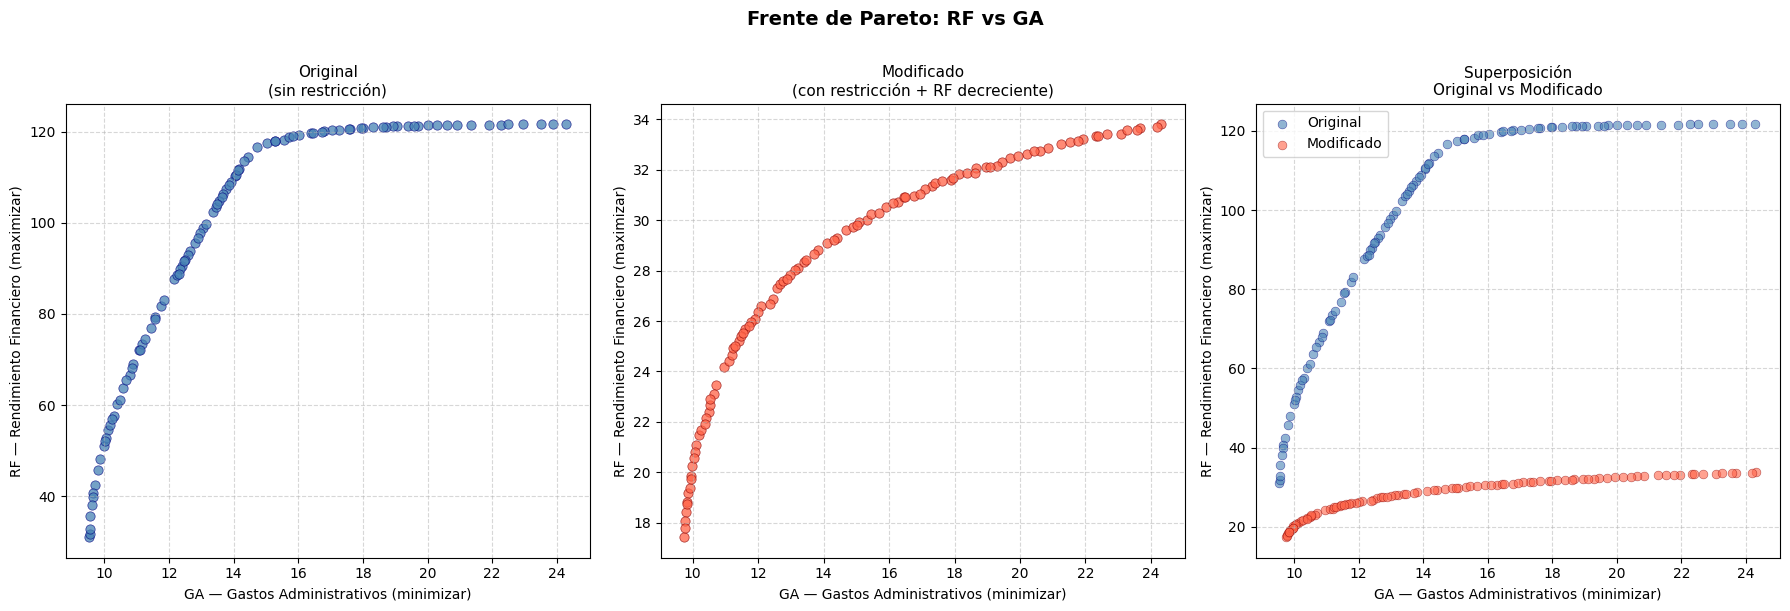

📌 Figura guardada: 01_frente_pareto_comparacion.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Frente de Pareto: RF vs GA", fontsize=14, fontweight='bold', y=1.01)

# ────────────────────────────────────────────────────────────────────────────
# Panel izquierdo: Original
# ────────────────────────────────────────────────────────────────────────────
axes[0].scatter(orig_ga, orig_rf, s=45, color='steelblue', alpha=0.75, edgecolors='navy', linewidths=0.5)
axes[0].set_title("Original\n(sin restricción)", fontsize=11)
axes[0].set_xlabel("GA — Gastos Administrativos (minimizar)")
axes[0].set_ylabel("RF — Rendimiento Financiero (maximizar)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# ────────────────────────────────────────────────────────────────────────────
# Panel central: Modificado
# ────────────────────────────────────────────────────────────────────────────
axes[1].scatter(mod_ga, mod_rf, s=45, color='tomato', alpha=0.75, edgecolors='darkred', linewidths=0.5)
axes[1].set_title("Modificado\n(con restricción + RF decreciente)", fontsize=11)
axes[1].set_xlabel("GA — Gastos Administrativos (minimizar)")
axes[1].set_ylabel("RF — Rendimiento Financiero (maximizar)")
axes[1].grid(True, linestyle='--', alpha=0.5)

# ────────────────────────────────────────────────────────────────────────────
# Panel derecho: Superposición para comparación directa
# ────────────────────────────────────────────────────────────────────────────
axes[2].scatter(orig_ga, orig_rf, s=40, color='steelblue', alpha=0.6,
                edgecolors='navy', linewidths=0.4, label='Original')
axes[2].scatter(mod_ga,  mod_rf,  s=40, color='tomato',    alpha=0.6,
                edgecolors='darkred', linewidths=0.4, label='Modificado')
axes[2].set_title("Superposición\nOriginal vs Modificado", fontsize=11)
axes[2].set_xlabel("GA — Gastos Administrativos (minimizar)")
axes[2].set_ylabel("RF — Rendimiento Financiero (maximizar)")
axes[2].legend(fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('outputs/01_frente_pareto_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Figura guardada: 01_frente_pareto_comparacion.png")

---
## Sección 6 — Espacio de decisión coloreado por RF

**Qué:** Graficamos las soluciones del frente de Pareto en el espacio (NIT, GES) con colores según el valor de RF.  
**Por qué:** El espacio de objetivos muestra *qué* se logra, pero el espacio de decisión muestra *cómo*: qué combinaciones de inversión tecnológica y externalización producen esos resultados.  
**Para qué:** Responder la pregunta **c** del enunciado: qué estrategias (NIT, GES) son más prometedoras bajo las nuevas condiciones. Un color amarillo/claro indica mayor RF.

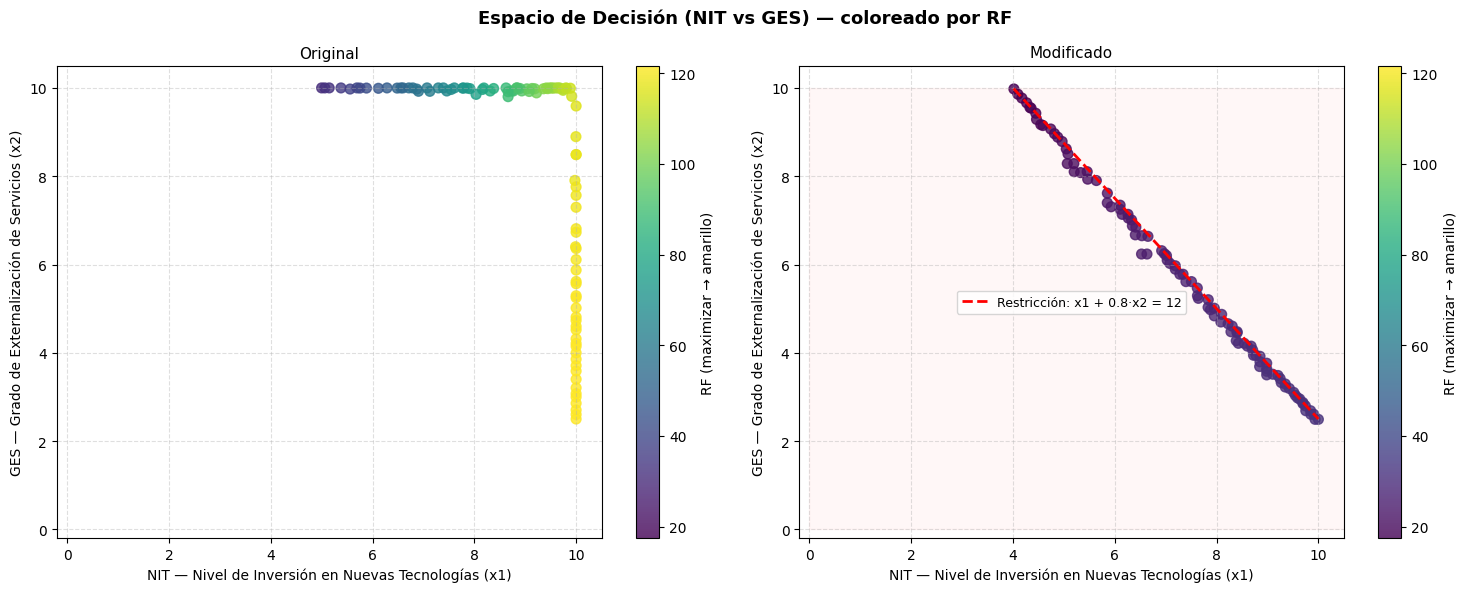

📌 Figura guardada: 02_espacio_decision_RF.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Espacio de Decisión (NIT vs GES) — coloreado por RF", fontsize=13, fontweight='bold')

# Escala de color común para comparación justa
vmin_rf = min(orig_rf.min(), mod_rf.min())
vmax_rf = max(orig_rf.max(), mod_rf.max())

# ── Original ─────────────────────────────────────────────────────────────────
sc1 = axes[0].scatter(orig_x1, orig_x2, c=orig_rf, cmap='viridis',
                      vmin=vmin_rf, vmax=vmax_rf, s=50, alpha=0.8)
axes[0].set_title("Original", fontsize=11)
axes[0].set_xlabel("NIT — Nivel de Inversión en Nuevas Tecnologías (x1)")
axes[0].set_ylabel("GES — Grado de Externalización de Servicios (x2)")
axes[0].set_xlim(-0.2, 10.5)
axes[0].set_ylim(-0.2, 10.5)
axes[0].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc1, ax=axes[0], label='RF (maximizar → amarillo)')

# ── Modificado ────────────────────────────────────────────────────────────────
sc2 = axes[1].scatter(mod_x1, mod_x2, c=mod_rf, cmap='viridis',
                      vmin=vmin_rf, vmax=vmax_rf, s=50, alpha=0.8)
axes[1].set_title("Modificado", fontsize=11)
axes[1].set_xlabel("NIT — Nivel de Inversión en Nuevas Tecnologías (x1)")
axes[1].set_ylabel("GES — Grado de Externalización de Servicios (x2)")
axes[1].set_xlim(-0.2, 10.5)
axes[1].set_ylim(-0.2, 10.5)
axes[1].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc2, ax=axes[1], label='RF (maximizar → amarillo)')

# Dibujamos la línea de restricción presupuestaria en el panel modificado:
# 1*x1 + 0.8*x2 = 12  →  x2 = (12 - x1) / 0.8
x1_line = np.linspace(0, 10, 300)
x2_line = (12 - x1_line) / 0.8
mask_valid = (x2_line >= 0) & (x2_line <= 10)
axes[1].plot(x1_line[mask_valid], x2_line[mask_valid],
             'r--', linewidth=2, label='Restricción: x1 + 0.8·x2 = 12')
axes[1].fill_betweenx([0, 10], 0, 12, alpha=0.03, color='red')  # región infactible
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/02_espacio_decision_RF.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Figura guardada: 02_espacio_decision_RF.png")

---
## Sección 7 — Espacio de decisión coloreado por GA

**Qué:** Igual que la sección anterior, pero los puntos se colorean según el valor de GA.  
**Por qué:** GA y RF responden de distinta manera a las variables de decisión. Ver GA en el espacio de decisión revela cuáles niveles de NIT/GES llevan a menores gastos administrativos.  
**Para qué:** Completar el análisis del espacio de decisión y apoyar la elección de una solución de compromiso en la Sección 9.

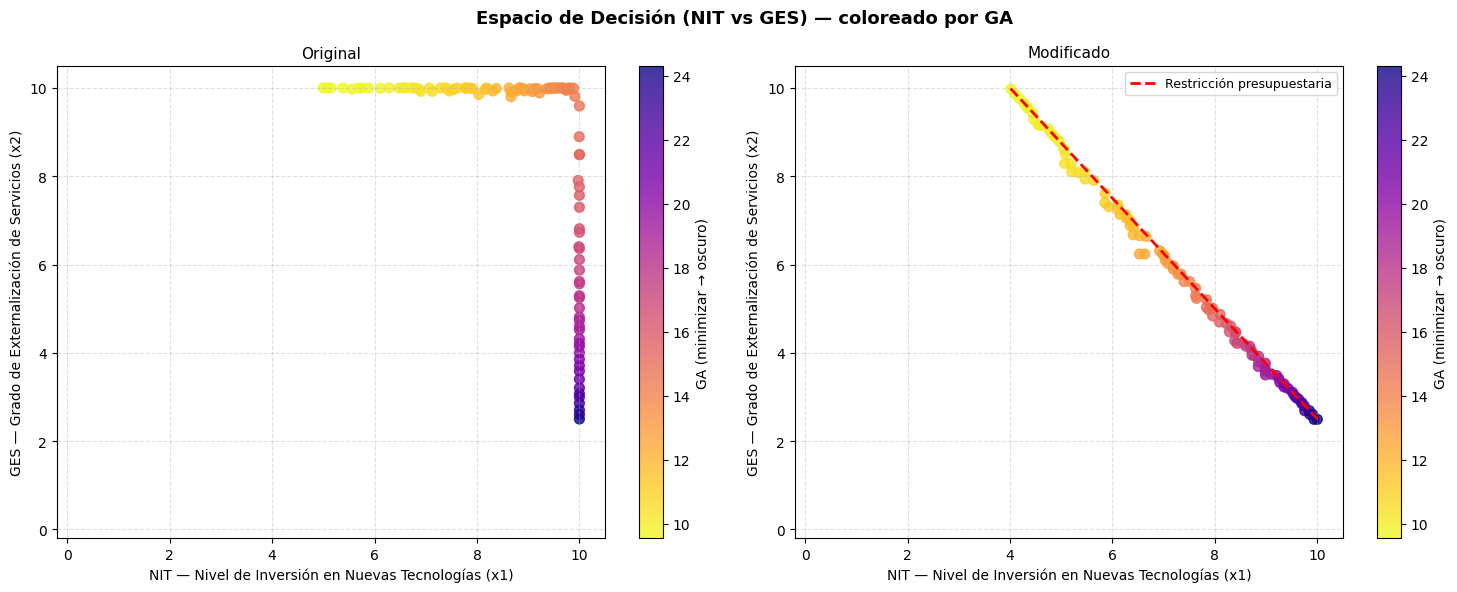

📌 Figura guardada: 03_espacio_decision_GA.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Espacio de Decisión (NIT vs GES) — coloreado por GA", fontsize=13, fontweight='bold')

# Escala de color común
vmin_ga = min(orig_ga.min(), mod_ga.min())
vmax_ga = max(orig_ga.max(), mod_ga.max())

# ── Original ─────────────────────────────────────────────────────────────────
# cmap='plasma_r': colores claros = GA alto (malo), oscuros = GA bajo (bueno)
sc3 = axes[0].scatter(orig_x1, orig_x2, c=orig_ga, cmap='plasma_r',
                      vmin=vmin_ga, vmax=vmax_ga, s=50, alpha=0.8)
axes[0].set_title("Original", fontsize=11)
axes[0].set_xlabel("NIT — Nivel de Inversión en Nuevas Tecnologías (x1)")
axes[0].set_ylabel("GES — Grado de Externalización de Servicios (x2)")
axes[0].set_xlim(-0.2, 10.5)
axes[0].set_ylim(-0.2, 10.5)
axes[0].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc3, ax=axes[0], label='GA (minimizar → oscuro)')

# ── Modificado ────────────────────────────────────────────────────────────────
sc4 = axes[1].scatter(mod_x1, mod_x2, c=mod_ga, cmap='plasma_r',
                      vmin=vmin_ga, vmax=vmax_ga, s=50, alpha=0.8)
axes[1].set_title("Modificado", fontsize=11)
axes[1].set_xlabel("NIT — Nivel de Inversión en Nuevas Tecnologías (x1)")
axes[1].set_ylabel("GES — Grado de Externalización de Servicios (x2)")
axes[1].set_xlim(-0.2, 10.5)
axes[1].set_ylim(-0.2, 10.5)
axes[1].grid(True, linestyle='--', alpha=0.4)
plt.colorbar(sc4, ax=axes[1], label='GA (minimizar → oscuro)')

# Línea de restricción presupuestaria
axes[1].plot(x1_line[mask_valid], x2_line[mask_valid],
             'r--', linewidth=2, label='Restricción presupuestaria')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/03_espacio_decision_GA.png', dpi=150, bbox_inches='tight')
plt.show()
print("📌 Figura guardada: 03_espacio_decision_GA.png")

---
## Sección 8 — Verificación del cumplimiento de la restricción

**Qué:** Comprobamos cuántas soluciones del frente modificado violan la restricción presupuestaria `1·x1 + 0.8·x2 ≤ 12`.  
**Por qué:** pymoo puede devolver soluciones ligeramente infactibles dependiendo de la configuración del algoritmo; verificarlo asegura integridad de los resultados.  
**Para qué:** Validar que el análisis de las secciones anteriores se basa en soluciones factibles.

🔍 Verificación de restricción presupuestaria (1·x1 + 0.8·x2 ≤ 12)
   Gasto presupuestario mínimo : 11.5156
   Gasto presupuestario máximo : 11.9993  (límite: 12.0)
   Soluciones violadoras       : 0 de 100
   ✅ Todas las soluciones cumplen la restricción.


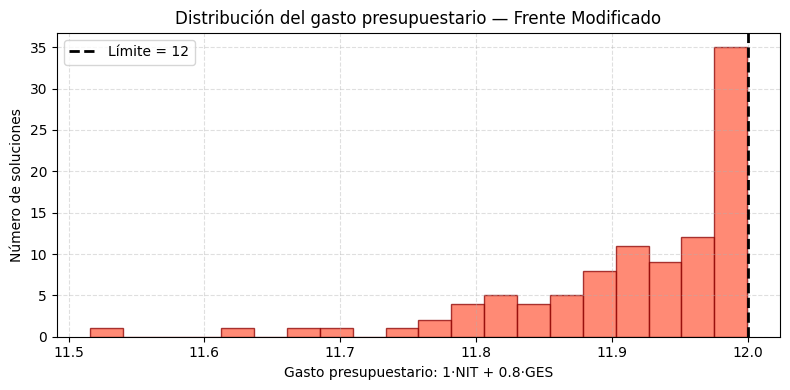

In [8]:
# Calculamos el gasto presupuestario de cada solución del frente modificado
gasto_presupuestario = 1.0 * mod_x1 + 0.8 * mod_x2
violaciones = np.sum(gasto_presupuestario > 12.0 + 1e-6)  # tolerancia numérica

print("🔍 Verificación de restricción presupuestaria (1·x1 + 0.8·x2 ≤ 12)")
print(f"   Gasto presupuestario mínimo : {gasto_presupuestario.min():.4f}")
print(f"   Gasto presupuestario máximo : {gasto_presupuestario.max():.4f}  (límite: 12.0)")
print(f"   Soluciones violadoras       : {violaciones} de {len(mod_x1)}")

if violaciones == 0:
    print("   ✅ Todas las soluciones cumplen la restricción.")
else:
    print("   ⚠️  Hay soluciones infactibles — revisar parámetros del algoritmo.")

# Distribución del gasto presupuestario
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gasto_presupuestario, bins=20, color='tomato', alpha=0.75, edgecolor='darkred')
ax.axvline(12.0, color='black', linestyle='--', linewidth=2, label='Límite = 12')
ax.set_xlabel("Gasto presupuestario: 1·NIT + 0.8·GES")
ax.set_ylabel("Número de soluciones")
ax.set_title("Distribución del gasto presupuestario — Frente Modificado")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('outputs/04_verificacion_restriccion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 9 — Análisis y respuestas a las preguntas del enunciado

**Qué:** Seleccionamos una solución de compromiso del frente modificado y respondemos las preguntas del enunciado con soporte cuantitativo.  
**Por qué:** Un frente de Pareto no da una única respuesta; la decisión final requiere un criterio adicional. Usamos el método del **punto de rodilla** (knee point): la solución más lejana de la línea que une los extremos del frente, que representa el mayor beneficio relativo por unidad de sacrificio.  
**Para qué:** Demostrar que la toma de decisiones post-optimización es tan importante como la optimización misma.

🎯 SOLUCIÓN RECOMENDADA (Punto de Rodilla)
──────────────────────────────────────────────────
   NIT (x1)              = 7.507
   GES (x2)              = 5.613
   RF obtenido           = 28.823  (maximizar)
   GA obtenido           = 13.818  (minimizar)
   Gasto presupuestario  = 11.997  (límite: 12.0)
──────────────────────────────────────────────────


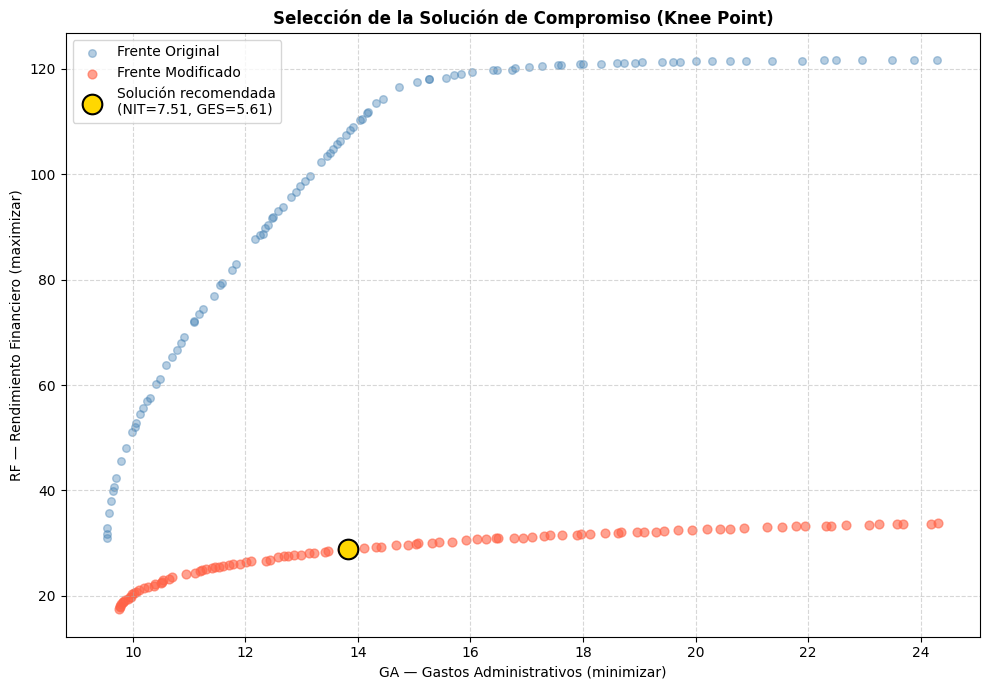

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# SELECCIÓN DE SOLUCIÓN: MÉTODO DEL PUNTO DE RODILLA (KNEE POINT)
# ══════════════════════════════════════════════════════════════════════════════
# Normalizamos RF y GA al rango [0,1] para calcular distancias en escala común.
# El knee point es el punto del frente más alejado de la línea recta entre
# el extremo de mayor RF (mínimo GA posible) y el de menor GA (máximo RF posible).

rf_norm = (mod_rf - mod_rf.min()) / (mod_rf.max() - mod_rf.min())
ga_norm = (mod_ga - mod_ga.min()) / (mod_ga.max() - mod_ga.min())

# Extremos del frente normalizado
A = np.array([ga_norm[np.argmax(rf_norm)], rf_norm[np.argmax(rf_norm)]])  # máximo RF
B = np.array([ga_norm[np.argmin(ga_norm)], rf_norm[np.argmin(ga_norm)]])  # mínimo GA

# Distancia de cada punto a la línea AB
def distancia_a_linea(P, A, B):
    AB = B - A
    AP = P - A
    return np.abs(AB[0]*AP[1] - AB[1]*AP[0]) / np.linalg.norm(AB)

distancias = np.array([
    distancia_a_linea(np.array([ga_norm[i], rf_norm[i]]), A, B)
    for i in range(len(mod_rf))
])

idx_knee = np.argmax(distancias)
sol_nit  = mod_x1[idx_knee]
sol_ges  = mod_x2[idx_knee]
sol_rf   = mod_rf[idx_knee]
sol_ga   = mod_ga[idx_knee]
sol_presupuesto = 1.0 * sol_nit + 0.8 * sol_ges

print("🎯 SOLUCIÓN RECOMENDADA (Punto de Rodilla)")
print("─" * 50)
print(f"   NIT (x1)              = {sol_nit:.3f}")
print(f"   GES (x2)              = {sol_ges:.3f}")
print(f"   RF obtenido           = {sol_rf:.3f}  (maximizar)")
print(f"   GA obtenido           = {sol_ga:.3f}  (minimizar)")
print(f"   Gasto presupuestario  = {sol_presupuesto:.3f}  (límite: 12.0)")
print("─" * 50)

# ── Visualización del frente con la solución recomendada destacada ─────────
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(orig_ga, orig_rf, s=30, color='steelblue', alpha=0.4, label='Frente Original')
ax.scatter(mod_ga,  mod_rf,  s=40, color='tomato',    alpha=0.6, label='Frente Modificado')
ax.scatter(sol_ga,  sol_rf,  s=200, color='gold', edgecolors='black',
           linewidths=1.5, zorder=5, label=f'Solución recomendada\n(NIT={sol_nit:.2f}, GES={sol_ges:.2f})')
ax.set_xlabel("GA — Gastos Administrativos (minimizar)")
ax.set_ylabel("RF — Rendimiento Financiero (maximizar)")
ax.set_title("Selección de la Solución de Compromiso (Knee Point)", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('outputs/05_solucion_recomendada.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 10 — Respuestas formales a las preguntas del enunciado

**Qué:** Consolidamos las conclusiones analíticas del estudio.  
**Por qué:** Las gráficas muestran patrones, pero es necesario articularlos en lenguaje de negocio para que sean útiles a la dirección.  
**Para qué:** Entregar el componente de *informe* que pide el enunciado.

In [ ]:
# ── Este bloque imprime el informe de análisis ─────────────────────────────
# (Puede exportarse a Markdown o Word para su entrega)

print("=" * 70)
print("INFORME DE ANÁLISIS — NSGA-II: ORIGINAL vs. MODIFICADO")
print("=" * 70)

print("""
─────────────────────────────────────────────────────────────────────
Pregunta a: Impacto de la restricción presupuestaria en el Frente de Pareto
─────────────────────────────────────────────────────────────────────
La restricción 1·x1 + 0.8·x2 ≤ 12 reduce el espacio factible de
soluciones. Comparando los dos frentes:

  • El RF máximo cae de {:.2f} (original) a {:.2f} (modificado),
    una reducción del {:.1f}%.
  • El rango de GA en el frente se estrecha: antes llegaba hasta GA ≈ {:.2f};
    ahora el máximo es ≈ {:.2f}.
  • Las soluciones con NIT alto (x1 > 10 si se permitiera, o combinaciones
    altas de ambas variables) ya no son alcanzables. Específicamente,
    cualquier punto con 1·x1 + 0.8·x2 > 12 queda excluido.
  • El frente modificado es más compacto en el espacio de objetivos:
    menos variedad de compromisos disponibles para la dirección.
""".format(orig_rf.max(), mod_rf.max(),
           100*(1 - mod_rf.max()/orig_rf.max()),
           orig_ga.max(), mod_ga.max()))

print("""
─────────────────────────────────────────────────────────────────────
Pregunta b: Impacto del cambio de función RF (rendimientos decrecientes)
─────────────────────────────────────────────────────────────────────
El cambio de (x1+1)² → 10·√(x1+1) tiene tres efectos observables:

  1. DESPLAZAMIENTO HACIA ABAJO del frente: los valores máximos de RF
     son mucho menores porque la raíz cuadrada crece más lentamente
     que el cuadrado para x1 > ~1.5.
  2. APLANAMIENTO de la curva: con RF decreciente, pasar de NIT bajo
     a NIT alto ya no produce grandes ganancias de RF, así que la
     "pendiente" del trade-off RF/GA es menos pronunciada.
  3. REDISTRIBUCIÓN en el espacio de decisión: el algoritmo ya no
     favorece valores extremos de x1 para maximizar RF; los puntos del
     frente se distribuyen en valores moderados de NIT.
""")

print("""
─────────────────────────────────────────────────────────────────────
Pregunta c: Estrategias prometedoras y solución recomendada
─────────────────────────────────────────────────────────────────────
Estrategias más prometedoras bajo las nuevas condiciones:
  • NIT moderado-bajo (x1 ≈ {:.1f}–{:.1f}): dado el rendimiento decreciente,
    no compensa gastar todo el presupuesto en tecnología.
  • GES moderado-alto (x2 ≈ {:.1f}–{:.1f}): la externalización sigue siendo
    la palanca más eficiente para reducir GA sin sacrificar mucho RF.
  • El presupuesto debe repartirse: destinar ~{:.0f} unidades a NIT y
    ~{:.0f} unidades a GES es más eficiente que concentrarlo en una sola.

Solución recomendada (punto de rodilla):
  NIT = {:.2f}  |  GES = {:.2f}  |  RF = {:.2f}  |  GA = {:.2f}
  Presupuesto usado: {:.2f} / 12.00

  Justificación: Esta solución maximiza la ganancia conjunta en ambos
  objetivos. En el frente normalizado es el punto más alejado de la
  diagonal, lo que significa que ofrece un RF sustancialmente alto sin
  que los gastos administrativos sean desproporcionados. Desde la
  perspectiva de negocio: se recomienda una inversión tecnológica
  contenida (NIT moderado) combinada con externalización significativa,
  aprovechando la reducción de gastos directos que esta aporta.
""".format(
    mod_x1.min(), np.percentile(mod_x1, 50),
    np.percentile(mod_x2, 50), mod_x2.max(),
    sol_nit, sol_ges,
    sol_nit, sol_ges, sol_rf, sol_ga, sol_presupuesto
))

print("=" * 70)

---
## Sección 11 — Tabla completa de soluciones del frente modificado

**Qué:** Mostramos todas las soluciones del frente de Pareto modificado ordenadas por RF descendente.  
**Por qué:** La dirección puede querer filtrar soluciones por criterios adicionales (e.g., GA < 15, NIT < 5). Tener la tabla completa lo facilita.  
**Para qué:** Soporte cuantitativo completo para la toma de decisiones.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# Construimos la tabla ordenada por RF descendente
orden = np.argsort(-mod_rf)   # índices de mayor a menor RF

print(f"{'#':<4} {'NIT (x1)':>10} {'GES (x2)':>10} {'RF':>10} {'GA':>10} {'Presup.':>10}")
print("─" * 58)
for rank, i in enumerate(orden, 1):
    presup = 1.0 * mod_x1[i] + 0.8 * mod_x2[i]
    marker = " ◀ recomendada" if i == idx_knee else ""
    print(f"{rank:<4} {mod_x1[i]:>10.3f} {mod_x2[i]:>10.3f} "
          f"{mod_rf[i]:>10.3f} {mod_ga[i]:>10.3f} {presup:>10.3f}{marker}")

print("─" * 58)
print(f"Total de soluciones en el frente: {len(mod_rf)}")